# FeCoNiCrV K/CTE Optimization: Three-Way Comparison

**Objective:** Maximize K / |CTE| ratio

**Strategies:**
1. Pure QEHVI (Full Exploitation)
2. Pure MESMO (Full Exploration)
3. LLM Agent-Driven BO (Adaptive)

This notebook runs all three strategies and compares their performance.
- All strategies use the SAME initial samples for fair comparison
- Proper seeding ensures reproducibility
- Results are saved to unique directories to avoid duplicates

## Imports and Global Setup

In [1]:
import os
import gc
import time
import shutil
from datetime import datetime
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple

import sys
sys.path.append(".")

from dotenv import load_dotenv
load_dotenv()

from core.design_space import DesignSpace
from core.truth_interface import TruthModelEvaluator
from core.gp_models import GPModelManager
from core.acq_ucb import AcquisitionFunctionManager
from core.agent_manager import BOAgent, ResourceEvent
from core.fixed_policy import PureExploitation, PureExploration
from core.logging_utils import LoggingManager
from core.visualization import VisualizationManager

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.double

print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
PyTorch version: 2.10.0+cu128


## Problem Configuration (FeCoNiCrV)

In [2]:
# Design space: 5D Fe-Co-Ni-Cr-V simplex
COMPONENTS = [
    ("Fe", 0.10, 0.40),
    ("Co", 0.10, 0.40),
    ("Ni", 0.10, 0.40),
    ("Cr", 0.10, 0.40),
    ("V",  0.10, 0.40),
]
STEP = 0.025
SEED = 42 # Master seed for reproducibility

design_space = DesignSpace(components=COMPONENTS, step=STEP, seed=SEED)
bounds_np = design_space.get_bounds()  # (2, 5)
bounds_t = torch.tensor(bounds_np, dtype=DTYPE, device=DEVICE)

print(f"\nDesign space created with {len(design_space.space)} valid compositions")

# Truth model paths (RF + scalers)
MODEL_PATH = "ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl"
X_SCALER_PATH = "ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/x_scaler.pkl"
Y_SCALER_PATH = "ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/y_scaler.pkl"

def postprocess_outputs(preds_raw: np.ndarray) -> np.ndarray:
    """
    RF output (based on TARGET_COLS order):
      preds_raw[:,0] = CTE_micro (x 10^(-6) 1/K)
      preds_raw[:,1] = K (W/mK)
    
    We want:
      Y[:,0] = |CTE| (absolute value)
      Y[:,1] = K
    """
    cte = -1.0 * preds_raw[:, 0]  # CTE is at index 0
    k = preds_raw[:, 1]           # K is at index 1
    return np.column_stack([cte, k])

# Objective names
OBJ1_NAME = "CTE"  # Y[:,0]
OBJ2_NAME = "K"    # Y[:,1]

# Score function: maximize K / |CTE|
def score_fn(Y: np.ndarray) -> np.ndarray:
    cte = Y[:, 0]  # |CTE|
    k = Y[:, 1]    # K
    return k / (np.abs(cte) + 1e-12)

SCORE_NAME = "K / |CTE|"

print(f"\nObjectives: {OBJ1_NAME}, {OBJ2_NAME}")
print(f"Score metric: {SCORE_NAME}")

[DesignSpace] Generated 8976 valid compositions for 5 components: Fe, Co, Ni, Cr, V

Design space created with 8976 valid compositions

Objectives: CTE, K
Score metric: K / |CTE|


## Compute Output Normalization Parameters

In [3]:
print("\n" + "="*80)
print("COMPUTING OUTPUT NORMALIZATION PARAMETERS")
print("="*80)

# Sample design space to estimate output statistics
print("\n[Setup] Sampling design space to compute normalization statistics...")
sample_X = design_space.sample(n=100, method='sobol')

# Create temporary evaluator WITHOUT normalization to get raw outputs
temp_evaluator = TruthModelEvaluator(
    model_path=MODEL_PATH,
    x_scaler_path=X_SCALER_PATH,
    y_scaler_path=Y_SCALER_PATH,
    postprocess_outputs=postprocess_outputs,
    normalize_outputs=False,  # CRITICAL: Get raw outputs first
)

# Evaluate sample to get output statistics
sample_result = temp_evaluator.evaluate(sample_X)
sample_Y = sample_result.y

# Compute normalization parameters
y_mean = np.mean(sample_Y, axis=0)
y_std = np.std(sample_Y, axis=0)

print(f"\nNormalization parameters computed from {len(sample_X)} samples:")
print(f"  {OBJ1_NAME}: mean={y_mean[0]:.4f}, std={y_std[0]:.4f}")
print(f"  {OBJ2_NAME}: mean={y_mean[1]:.4f}, std={y_std[1]:.4f}")
print(f"  Scale ratio (std[K]/std[CTE]): {y_std[1]/y_std[0]:.2f}x")

# Store normalization parameters
normalization_params = {'mean': y_mean, 'std': y_std}

# Clean up temporary evaluator
temp_evaluator.cleanup()
del temp_evaluator
gc.collect()

print("\n✓ Normalization parameters computed successfully")
print("="*80)


COMPUTING OUTPUT NORMALIZATION PARAMETERS

[Setup] Sampling design space to compute normalization statistics...
[TruthEvaluator] Loading model from ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2

Normalization parameters computed from 100 samples:
  CTE: mean=-12.2504, std=2.4196
  K: mean=10.9706, std=12.8937
  Scale ratio (std[K]/std[CTE]): 5.33x
[TruthEvaluator] Cleanup called

✓ Normalization parameters computed successfully


c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: Inconsiste

## BO Configuration

In [4]:
# BO parameters
INIT_N = 5              # Initial random samples
ITERS = 5              # BO iterations
MC_SAMPLES = 256        # Monte Carlo samples for acquisition
POOL_SUBSAMPLE = 5000   # Subsample pool size (None = use full space)
TOTAL_BATCH_SIZE = 5    # Points per iteration

# Resource constraints (for LLM agent)
TOTAL_BUDGET = 10000.0    # $ total budget
TOTAL_TIME = 20.0         # weeks total time
COST_PER_POINT = 100.0    # $ per experiment
TIME_PER_ITERATION = 1.0  # weeks per iteration

# LLM agent configuration
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
AGENT_MODEL = "gpt-4o"
AGENT_TEMPERATURE = 0.7
MAX_REASONING_STEPS = 5

PROBLEM_DESCRIPTION = """
High Entropy Alloy (HEA) optimization in the Fe-Co-Ni-Cr-V composition space.

Objectives:
- Minimize CTE (Coefficient of Thermal Expansion)
- Maximize K (Thermal Conductivity)

Goal: Maximize K / |CTE| ratio

Input space: 5D compositions (Fe, Co, Ni, Cr, V), each in [0.1, 0.4], summing to 1.0.

You should balance exploration and exploitation given the qEHVI and MO-MESMO 
acquisition values for each option to best reach the goal within budget and time constraints.
"""

# Output configuration - Use timestamp to avoid overwriting
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"results/FeCoNiCrV_K_CTE_Comparison_{TIMESTAMP}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CREATE_VIS = True   # Create visualizations (pentagon plots for 5D)
CREATE_GIF = True   # Create animated GIFs

print(f"\nBO Configuration:")
print(f"  Initial samples: {INIT_N}")
print(f"  Iterations: {ITERS}")
print(f"  Batch size: {TOTAL_BATCH_SIZE}")
print(f"  Total evaluations: {INIT_N + ITERS * TOTAL_BATCH_SIZE}")
print(f"\nOutput directory: {OUTPUT_DIR}")


BO Configuration:
  Initial samples: 5
  Iterations: 5
  Batch size: 5
  Total evaluations: 30

Output directory: results/FeCoNiCrV_K_CTE_Comparison_20260211_153708


## Generate Shared Initial Samples

**CRITICAL:** All strategies must start with the same initial samples for fair comparison.

In [5]:
# Set seed and generate initial samples ONCE
print(f"\n{'='*80}")
print("GENERATING SHARED INITIAL SAMPLES")
print(f"{'='*80}")

# Reset seeds
np.random.seed(SEED)
torch.manual_seed(SEED)

# Sample initial points
X0_SHARED = design_space.sample(INIT_N, method="random")
print(f"\nSampled {INIT_N} initial compositions:")
for i, x in enumerate(X0_SHARED):
    comp_str = ", ".join([f"{label}={val:.3f}" for label, val in zip(design_space.labels, x)])
    print(f"  {i+1}. {comp_str}")

# Create temporary evaluator for initial evaluation
# This evaluator will use normalization since we need raw outputs for display
# but normalized outputs for the actual BO runs
temp_evaluator = TruthModelEvaluator(
    model_path=MODEL_PATH,
    x_scaler_path=X_SCALER_PATH,
    y_scaler_path=Y_SCALER_PATH,
    postprocess_outputs=postprocess_outputs,
    normalize_outputs=False,  # Get raw outputs for display
)

# Evaluate initial points
result0 = temp_evaluator.evaluate(X0_SHARED)
Y0_SHARED_RAW = result0.y  # These are RAW (denormalized) outputs

# Also get normalized version for BO strategies
temp_evaluator_norm = TruthModelEvaluator(
    model_path=MODEL_PATH,
    x_scaler_path=X_SCALER_PATH,
    y_scaler_path=Y_SCALER_PATH,
    postprocess_outputs=postprocess_outputs,
    normalize_outputs=True,
    normalization_params=normalization_params,
)

result0_norm = temp_evaluator_norm.evaluate(X0_SHARED)
Y0_SHARED_NORMALIZED = result0_norm.y  # Normalized for GP

# Clean up
temp_evaluator.cleanup()
temp_evaluator_norm.cleanup()
del temp_evaluator, temp_evaluator_norm
gc.collect()

print(f"\nInitial objective values (RAW scale for interpretability):")
for i, (cte, k) in enumerate(Y0_SHARED_RAW):
    score = score_fn(Y0_SHARED_RAW[i:i+1])[0]
    print(f"  {i+1}. CTE={cte:.4f}, K={k:.4f}, Score={score:.4f}")

# Save shared initial data (RAW outputs)
shared_init_path = os.path.join(OUTPUT_DIR, "shared_initial_samples.csv")
init_df = pd.DataFrame(X0_SHARED, columns=design_space.labels)
Y0_SHARED_RAW = np.abs(Y0_SHARED_RAW)
init_df["CTE"] = Y0_SHARED_RAW[:, 0]
init_df["K"] = Y0_SHARED_RAW[:, 1]
init_df["score"] = score_fn(Y0_SHARED_RAW)
init_df.to_csv(shared_init_path, index=False)
print(f"\nShared initial samples saved to: {shared_init_path}")

print(f"\n{'='*80}")
print("All experiments will use these exact same initial samples")
print(f"{'='*80}")


GENERATING SHARED INITIAL SAMPLES

Sampled 5 initial compositions:
  1. Fe=0.275, Co=0.100, Ni=0.125, Cr=0.150, V=0.350
  2. Fe=0.175, Co=0.150, Ni=0.300, Cr=0.100, V=0.275
  3. Fe=0.225, Co=0.175, Ni=0.200, Cr=0.275, V=0.125
  4. Fe=0.100, Co=0.250, Ni=0.200, Cr=0.325, V=0.125
  5. Fe=0.175, Co=0.150, Ni=0.175, Cr=0.175, V=0.325
[TruthEvaluator] Loading model from ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2
[TruthEvaluator] Loading model from ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl
[TruthEvaluator] Using provided normalization:
  Mean: [-12.25035938  10.9706266 ]
  Std:  [ 2.41957162 12.89373718]
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2
[TruthEvaluator] Cleanup called
[TruthEvaluator] Cleanup called

Initial objective values (RAW scale for interpretability):

c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: Inconsiste


  1. CTE=-10.0039, K=0.1000, Score=0.0100
  2. CTE=-10.9942, K=4.0849, Score=0.3715
  3. CTE=-11.5190, K=6.1244, Score=0.5317
  4. CTE=-11.5359, K=5.9221, Score=0.5134
  5. CTE=-10.0100, K=0.1614, Score=0.0161

Shared initial samples saved to: results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\shared_initial_samples.csv

All experiments will use these exact same initial samples


## Helper Function - Run BO Experiment

In [6]:
def run_bo_experiment(
    experiment_name: str,
    strategy,
    X0_init: np.ndarray,
    Y0_init_raw: np.ndarray,
    Y0_init_normalized: np.ndarray,
    normalization_params: dict,
    seed: int = SEED,
    create_visualization: bool = CREATE_VIS,
) -> Tuple[np.ndarray, np.ndarray, LoggingManager]:
    """
    Run a single BO experiment with a given strategy using qUCB acquisition.
    Only computes necessary allocation options:
    - PureExploitation: Only option 0 (all exploitation, beta=0.05)
    - PureExploration: Only option 5 (all exploration, beta=3.0)
    - BOAgent: All 6 options (adaptive selection)
  
    KEY WORKFLOW:
    1. GP and acquisition use NORMALIZED outputs (mean=0, std=1)
    2. Logging, scoring, and visualization use RAW (denormalized) outputs
    3. Evaluator returns normalized outputs, which we denormalize when needed
    
    Args:
        experiment_name: Name of this experiment
        strategy: PureExploitation, PureExploration, or BOAgent
        X0_init: Shared initial X samples (INIT_N, d)
        Y0_init_raw: Shared initial Y values in ORIGINAL scale (INIT_N, 2)
        Y0_init_normalized: Shared initial Y values NORMALIZED (INIT_N, 2)
        normalization_params: Dict with 'mean' and 'std' arrays
        seed: Random seed for BO iterations
        create_visualization: Whether to create visualizations
  
    Returns:
        X_history: (n, 5) final input history
        Y_history: (n, 2) final output history
        logger: LoggingManager instance
    """
    print(f"\n{'='*80}")
    print(f"[Experiment] {experiment_name}")
    print(f"[Strategy] {type(strategy).__name__}")
    print(f"{'='*80}")
    
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    evaluator = TruthModelEvaluator(
        model_path=MODEL_PATH,
        x_scaler_path=X_SCALER_PATH,
        y_scaler_path=Y_SCALER_PATH,
        postprocess_outputs=postprocess_outputs,
        normalize_outputs=True,
        normalization_params=normalization_params,
    )
  
    gp_manager = GPModelManager(bounds=bounds_t)
    acq_manager = AcquisitionFunctionManager(
        bounds=bounds_t,
        num_restarts=3,
        raw_samples=256,
        exploitation_beta=0.05,
        exploration_beta=3.0,
    )
    
    exp_dir = os.path.join(OUTPUT_DIR, experiment_name)
    os.makedirs(exp_dir, exist_ok=True)
    logger = LoggingManager(exp_dir, experiment_name)
    
    vis_manager = None
    if create_visualization:
        vis_manager = VisualizationManager(
            design_space=design_space,
            log_dir=exp_dir,
            experiment_name=experiment_name,
            normalization_params=normalization_params,
            obj1_name=OBJ1_NAME,
            obj2_name=OBJ2_NAME,
        )
    
    print(f"\n[Init] Using {len(X0_init)} shared initial samples")
    
    X_torch = torch.tensor(X0_init.copy(), dtype=DTYPE, device=DEVICE)
    Y_torch_normalized = torch.tensor(Y0_init_normalized.copy(), dtype=DTYPE, device=DEVICE)
    
    X_history_np = X0_init.copy()
    Y_history_raw_np = Y0_init_raw.copy()
    Y_history_normalized_np = Y0_init_normalized.copy()
  
    scores = score_fn(Y_history_raw_np)
    best_score = float(np.max(scores))
    print(f"[Init] Best {SCORE_NAME}: {best_score:.4f}")
  
    logger.log_iteration(
        iteration=0,
        X_history=X_history_np,
        Y_history=Y_history_raw_np,
        n_new_points=len(X0_init),
        strategy=strategy,
        timing=0.0,
        extra_info={"experiment": experiment_name, "shared_init": True},
        acquisition_data=None,
        score_fn=score_fn,
        obj1_name=OBJ1_NAME,
        obj2_name=OBJ2_NAME,
    )
    logger.log_evaluations(
        iteration=0,
        X_new=X0_init,
        Y_new=Y0_init_raw,
        score_fn=score_fn,
        obj1_name=OBJ1_NAME,
        obj2_name=OBJ2_NAME,
    )
  
    budget_remaining = TOTAL_BUDGET - (INIT_N * COST_PER_POINT)
    time_remaining = TOTAL_TIME - TIME_PER_ITERATION
    
    for iteration in range(1, ITERS + 1):
        iter_start = time.perf_counter()
        print(f"\n[Iter {iteration}/{ITERS}] Starting...")
        
        print("[GP] Fitting model on normalized outputs...")
        model = gp_manager.fit_model(X_torch, Y_torch_normalized)
        
        print("[Acq] Computing Pareto front on normalized outputs...")
        pareto_Y, ref_point = acq_manager.compute_pareto_front(Y_torch_normalized)
        
        if POOL_SUBSAMPLE is not None:
            X_pool_np = design_space.sample(POOL_SUBSAMPLE, method="sobol")
        else:
            X_pool_np = design_space.space.copy()
        X_pool = torch.tensor(X_pool_np, dtype=DTYPE, device=DEVICE)
        
        # ============================================================
        # Strategy-aware allocation computation
        # ============================================================
        strategy_name = type(strategy).__name__

        if strategy_name == "BOAgent":
            # LLM agent needs all 6 options for adaptive selection
            print("[Strategy] LLM Agent - Computing all 6 allocation options")
            allocation_results = acq_manager.compute_all_allocations(
                model=model,
                mc_samples=MC_SAMPLES,
                pareto_front=pareto_Y,
                reference_point=ref_point
            )

        elif "Exploit" in strategy_name or strategy_name == "PureExploitation":
            # Pure exploitation: all points with low beta (greedy)
            print("[Strategy] Pure Exploitation - Computing option 0 only (5 exploit, 0 explore)")
            allocation_results = acq_manager.compute_single_allocation(
                model=model,
                num_exploitation=TOTAL_BATCH_SIZE,
                num_exploration=0,
                mc_samples=MC_SAMPLES,
                pareto_front=pareto_Y,
                reference_point=ref_point
            )

        elif "Explor" in strategy_name or strategy_name == "PureExploration":
            # Pure exploration: all points with high beta (diverse)
            print("[Strategy] Pure Exploration - Computing option 5 only (0 exploit, 5 explore)")
            allocation_results = acq_manager.compute_single_allocation(
                model=model,
                num_exploitation=0,
                num_exploration=TOTAL_BATCH_SIZE,
                mc_samples=MC_SAMPLES,
                pareto_front=pareto_Y,
                reference_point=ref_point
            )

        else:
            # Fallback: compute all options
            print(f"[Strategy] Unknown strategy {strategy_name} - Computing all options")
            allocation_results = acq_manager.compute_all_allocations(
                model=model,
                mc_samples=MC_SAMPLES,
                pareto_front=pareto_Y,
                reference_point=ref_point
            )
        
        # ============================================================
        # UPDATED: Select points based on strategy (using new attributes)
        # ============================================================
        selected_idx = None  # Track which option was selected
        
        if isinstance(strategy, BOAgent):
            # LLM agent selection
            selected_idx, reasoning, selected_point_arrays = strategy.select_resource_allocation(
                iteration=iteration,
                budget_remaining=budget_remaining,
                time_remaining=time_remaining,
                cost_per_point=COST_PER_POINT,
                time_per_point=TIME_PER_ITERATION,
                X_history=X_torch.cpu().numpy(),
                Y_history=Y_torch_normalized.cpu().numpy(),
                allocation_results=allocation_results,
                max_batch_size=TOTAL_BATCH_SIZE,
                score_fn=score_fn,
            )
            if selected_point_arrays:
                X_new_np = np.vstack(selected_point_arrays)
            else:
                print("[Warning] Agent selected no points; using balanced fallback")
                selected_idx = 2  # Fallback to balanced option
                balanced_option = allocation_results.options[2]
                parts = []
                if balanced_option.exploitation_points.size > 0:
                    parts.append(balanced_option.exploitation_points)
                if balanced_option.exploration_points.size > 0:
                    parts.append(balanced_option.exploration_points)
                X_new_np = np.vstack(parts) if parts else design_space.sample(1, method="random")
            extra_info = {
                "agent_selected_option": selected_idx,
                "agent_reasoning": reasoning[:200] + "..." if len(reasoning) > 200 else reasoning,
                "budget_remaining": budget_remaining,
                "time_remaining": time_remaining,
            }
        else:
            # Fixed policy selection (PureExploitation or PureExploration)
            X_new_np, reasoning = strategy.select_points(allocation_results)
            
            # Determine selected_idx based on strategy type
            strategy_name = type(strategy).__name__
            if "Exploit" in strategy_name or strategy_name == "PureExploitation":
                selected_idx = 0  # Pure exploitation is always first (and only) option
            elif "Explor" in strategy_name or strategy_name == "PureExploration":
                # Pure exploration - if we computed all options, it's option 5
                # if we computed single allocation, it's option 0 (the only one)
                selected_idx = 5 if len(allocation_results.options) > 1 else 0
            else:
                selected_idx = 0  # Fallback
            
            extra_info = {
                "policy": type(strategy).__name__,
                "reasoning": reasoning,
            }
        
        # ============================================================
        # Extract HVI and Information Gain from selected option
        # ============================================================
        if selected_idx is not None and 0 <= selected_idx < len(allocation_results.options):
            selected_option = allocation_results.options[selected_idx]
            extra_info["hypervolume_improvement"] = float(selected_option.hypervolume_improvement)
            extra_info["information_gain"] = float(selected_option.information_gain)
            extra_info["n_optimization"] = selected_option.num_exploitation
            extra_info["n_exploration"] = selected_option.num_exploration
        else:
            # Fallback if something went wrong
            extra_info["hypervolume_improvement"] = None
            extra_info["information_gain"] = None
            extra_info["n_optimization"] = None
            extra_info["n_exploration"] = None
        
        # Evaluate selected points
        result_new = evaluator.evaluate(X_new_np)
        Y_new_normalized = result_new.y
        Y_new_raw = evaluator.denormalize(Y_new_normalized)
  
        # Update history
        X_history_np = np.vstack([X_history_np, X_new_np])
        Y_history_normalized_np = np.vstack([Y_history_normalized_np, Y_new_normalized])
        Y_history_raw_np = np.vstack([Y_history_raw_np, Y_new_raw])
        X_torch = torch.tensor(X_history_np, dtype=DTYPE, device=DEVICE)
        Y_torch_normalized = torch.tensor(Y_history_normalized_np, dtype=DTYPE, device=DEVICE)
        
        # Update resources
        points_used = len(X_new_np)
        budget_spent = points_used * COST_PER_POINT
        time_spent = TIME_PER_ITERATION
        budget_remaining -= budget_spent
        time_remaining -= time_spent
        iter_time = time.perf_counter() - iter_start
        
        # Logging
        logger.log_iteration(
            iteration=iteration,
            X_history=X_history_np,
            Y_history=Y_history_raw_np,
            n_new_points=points_used,
            strategy=strategy,
            timing=iter_time,
            extra_info=extra_info,
            acquisition_data=allocation_results,  # Changed from allocation_options
            score_fn=score_fn,
            obj1_name=OBJ1_NAME,
            obj2_name=OBJ2_NAME,
        )
        logger.log_evaluations(
            iteration=iteration,
            X_new=X_new_np,
            Y_new=Y_new_raw,
            score_fn=score_fn,
            obj1_name=OBJ1_NAME,
            obj2_name=OBJ2_NAME,
        )
        
        # Visualization
        if vis_manager is not None:
            vis_manager.create_iteration_plot(
                iteration=iteration,
                X_history=X_history_np,
                Y_history=Y_history_raw_np,
                X_new=X_new_np,
                model=model,
                bounds=bounds_t,
                selection_info=extra_info,
                score_fn=score_fn,
                score_name=SCORE_NAME,
                obj1_name=OBJ1_NAME,
                obj2_name=OBJ2_NAME,
            )
        
        # Print progress
        scores = score_fn(Y_history_raw_np)
        best_score = float(np.max(scores))
        mean_score = float(np.mean(scores))
        print(f"[Iter {iteration}] Complete in {iter_time:.2f}s")
        print(f"  Best {SCORE_NAME}: {best_score:.4f}")
        print(f"  Mean {SCORE_NAME}: {mean_score:.4f}")
        print(f"  Points evaluated: {points_used}")
        
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    logger.finalize()
    
    if vis_manager is not None and CREATE_GIF:
        vis_manager.create_gif(duration=2.0, gif_name=f"{experiment_name}.gif")
    
    if isinstance(strategy, BOAgent):
        strategy.save_global_memory()
    
    X_final = X_history_np
    Y_final = Y_history_raw_np
    scores_final = score_fn(Y_final)
    print(f"\n[{experiment_name}] Experiment complete!")
    print(f"  Total evaluations: {len(X_final)}")
    print(f"  Best {SCORE_NAME}: {np.max(scores_final):.4f}")
    print(f"  Mean {SCORE_NAME}: {np.mean(scores_final):.4f}")
    print(f"  Std {SCORE_NAME}: {np.std(scores_final):.4f}")
    
    return X_final, Y_final, logger

## Run Pure QEHVI

In [7]:
X_qehvi, Y_qehvi, logger_qehvi = run_bo_experiment(
    experiment_name="PureExploit",
    strategy=PureExploitation(),
    X0_init=X0_SHARED,
    Y0_init_raw=Y0_SHARED_RAW,
    Y0_init_normalized=Y0_SHARED_NORMALIZED,
    normalization_params=normalization_params,
    seed=SEED,
    create_visualization=CREATE_VIS,
)


[Experiment] PureExploit
[Strategy] PureExploitation
[TruthEvaluator] Loading model from ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl
[TruthEvaluator] Using provided normalization:
  Mean: [-12.25035938  10.9706266 ]
  Std:  [ 2.41957162 12.89373718]
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2
[Logger] Initialized logging in results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\PureExploit
[Logger] Files:
  - Convergence: results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\PureExploit\PureExploit_convergence.csv
  - Options: results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\PureExploit\PureExploit_options.csv
  - Evaluations: results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\PureExploit\PureExploit_evaluations.csv
[Viz] Using full design space (8976 points) for visualization
[Viz] Setup affine projection: projected 8976 points
[Viz] Cached visualization space on CPU: torch.Size([8976, 5])
[Viz] Initialized visualization in results/F

c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: Inconsiste

[Acq] Computing Pareto front on normalized outputs...
[Strategy] Pure Exploitation - Computing option 0 only (5 exploit, 0 explore)
[AcqFn] Computing allocation: 5 exploit + 0 explore
  Optimizing exploitation qUCB (beta=0.05, q=5)


c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\botorch\acquisition\multi_objective\monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


  → HVI: 0.2517, InfoGain: 1.2898
[Logger] Logged convergence for iteration 1
[Logger] Logged 1 options with 5 total points for iteration 1
[Logger] Logged 5 evaluations for iteration 1
[Viz] Predicted scores - Min: -0.0218, Max: 0.5379, Mean: 0.3744
[Viz] Created plot for iteration 1
[Iter 1] Complete in 16.37s
  Best K / |CTE|: 6.7800
  Mean K / |CTE|: 1.6866
  Points evaluated: 5


...


[Iter 5/5] Starting...
[GP] Fitting model on normalized outputs...
[Acq] Computing Pareto front on normalized outputs...
[Strategy] Pure Exploitation - Computing option 0 only (5 exploit, 0 explore)
[AcqFn] Computing allocation: 5 exploit + 0 explore
  Optimizing exploitation qUCB (beta=0.05, q=5)


c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\botorch\acquisition\multi_objective\monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


  → HVI: 0.1077, InfoGain: 0.3387
[Logger] Logged convergence for iteration 5
[Logger] Logged 1 options with 5 total points for iteration 5
[Logger] Logged 5 evaluations for iteration 5
[Viz] Predicted scores - Min: -0.1783, Max: 7.2804, Mean: 0.7970
[Viz] Created plot for iteration 5
[Iter 5] Complete in 10.72s
  Best K / |CTE|: 7.2737
  Mean K / |CTE|: 1.7816
  Points evaluated: 5


c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Logger] Finalized logging for PureExploit
[Viz] Determining minimum image dimensions for GIF...
[Viz] Created GIF at results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\PureExploit\PureExploit.gif

[PureExploit] Experiment complete!
  Total evaluations: 30
  Best K / |CTE|: 7.2737
  Mean K / |CTE|: 1.7816
  Std K / |CTE|: 2.6474


## Cell 7: Run Pure MESMO

In [8]:
# Run Pure MESMO experiment with shared initial samples
X_mesmo, Y_mesmo, logger_mesmo = run_bo_experiment(
    experiment_name="PureExplore",
    strategy=PureExploration(),
    X0_init=X0_SHARED,
    Y0_init_raw=Y0_SHARED_RAW,
    Y0_init_normalized=Y0_SHARED_NORMALIZED,
    normalization_params=normalization_params,
    seed=SEED,
    create_visualization=CREATE_VIS,
)


[Experiment] PureExplore
[Strategy] PureExploration
[TruthEvaluator] Loading model from ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl
[TruthEvaluator] Using provided normalization:
  Mean: [-12.25035938  10.9706266 ]
  Std:  [ 2.41957162 12.89373718]
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2
[Logger] Initialized logging in results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\PureExplore
[Logger] Files:
  - Convergence: results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\PureExplore\PureExplore_convergence.csv
  - Options: results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\PureExplore\PureExplore_options.csv
  - Evaluations: results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\PureExplore\PureExplore_evaluations.csv
[Viz] Using full design space (8976 points) for visualization
[Viz] Setup affine projection: projected 8976 points
[Viz] Cached visualization space on CPU: torch.Size([8976, 5])
[Viz] Initialized visualization in results/Fe

c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: Inconsiste

[Acq] Computing Pareto front on normalized outputs...
[Strategy] Pure Exploration - Computing option 5 only (0 exploit, 5 explore)
[AcqFn] Computing allocation: 0 exploit + 5 explore
  Optimizing exploration qUCB (beta=3.00, q=5)


c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\botorch\acquisition\multi_objective\monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


  → HVI: 0.2967, InfoGain: 1.2320
[Logger] Logged convergence for iteration 1
[Logger] Logged 1 options with 5 total points for iteration 1
[Logger] Logged 5 evaluations for iteration 1
[Viz] Predicted scores - Min: -0.0227, Max: 0.5385, Mean: 0.3743
[Viz] Created plot for iteration 1
[Iter 1] Complete in 30.59s
  Best K / |CTE|: 7.2737
  Mean K / |CTE|: 1.7680
  Points evaluated: 5


...


[Iter 5/5] Starting...
[GP] Fitting model on normalized outputs...
[Acq] Computing Pareto front on normalized outputs...
[Strategy] Pure Exploration - Computing option 5 only (0 exploit, 5 explore)
[AcqFn] Computing allocation: 0 exploit + 5 explore
  Optimizing exploration qUCB (beta=3.00, q=5)


c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\botorch\acquisition\multi_objective\monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


  → HVI: 0.4502, InfoGain: 0.0621
[Logger] Logged convergence for iteration 5
[Logger] Logged 1 options with 5 total points for iteration 5
[Logger] Logged 5 evaluations for iteration 5
[Viz] Predicted scores - Min: -0.1835, Max: 7.2652, Mean: 0.7918
[Viz] Created plot for iteration 5
[Iter 5] Complete in 9.31s
  Best K / |CTE|: 7.3039
  Mean K / |CTE|: 2.2434
  Points evaluated: 5


c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Logger] Finalized logging for PureExplore
[Viz] Determining minimum image dimensions for GIF...
[Viz] Created GIF at results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\PureExplore\PureExplore.gif

[PureExplore] Experiment complete!
  Total evaluations: 30
  Best K / |CTE|: 7.3039
  Mean K / |CTE|: 2.2434
  Std K / |CTE|: 2.4750


## Cell 8: Run LLM Agent-Driven BO

In [9]:
# Setup LLM agent
if OPENAI_API_KEY is None:
    raise ValueError("OPENAI_API_KEY environment variable not set!")

agent_log_dir = os.path.join(OUTPUT_DIR, "llm_agent", "agent_logs")
os.makedirs(agent_log_dir, exist_ok=True)

strategy_agent = BOAgent(
    model=AGENT_MODEL,
    temperature=AGENT_TEMPERATURE,
    api_key=OPENAI_API_KEY,
    log_dir=agent_log_dir,
    problem_description=PROBLEM_DESCRIPTION,
    obj1_name=OBJ1_NAME,
    obj2_name=OBJ2_NAME,
)

# Run LLM agent experiment
X_agent, Y_agent, logger_agent = run_bo_experiment(
    experiment_name="Agent",
    strategy=strategy_agent,
    X0_init=X0_SHARED,
    Y0_init_raw=Y0_SHARED_RAW,
    Y0_init_normalized=Y0_SHARED_NORMALIZED,
    normalization_params=normalization_params,
    seed=SEED,
    create_visualization=CREATE_VIS,
)


[Experiment] Agent
[Strategy] BOAgent
[TruthEvaluator] Loading model from ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl
[TruthEvaluator] Using provided normalization:
  Mean: [-12.25035938  10.9706266 ]
  Std:  [ 2.41957162 12.89373718]
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2
[Logger] Initialized logging in results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\Agent
[Logger] Files:
  - Convergence: results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\Agent\Agent_convergence.csv
  - Options: results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\Agent\Agent_options.csv
  - Evaluations: results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\Agent\Agent_evaluations.csv
[Viz] Using full design space (8976 points) for visualization
[Viz] Setup affine projection: projected 8976 points
[Viz] Cached visualization space on CPU: torch.Size([8976, 5])
[Viz] Initialized visualization in results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\Agent\visualiza

c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\base.py:463: Inconsiste

[Acq] Computing Pareto front on normalized outputs...
[Strategy] LLM Agent - Computing all 6 allocation options
[AcqFn] Computing all allocation options with qUCB

[AcqFn] Option 0: 5 exploit + 0 explore
  Optimizing exploitation qUCB (beta=0.05, q=5)


c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\botorch\acquisition\multi_objective\monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


  → HVI: 0.2520, InfoGain: 1.1957

[AcqFn] Option 1: 4 exploit + 1 explore
  Optimizing exploitation qUCB (beta=0.05, q=4)
  Optimizing exploration qUCB (beta=3.00, q=1)


...

  → HVI: 0.0288, InfoGain: 0.1022

[AcqFn] Option 5: 0 exploit + 5 explore
  Optimizing exploration qUCB (beta=3.00, q=5)


c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\botorch\acquisition\multi_objective\monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


  → HVI: 0.0304, InfoGain: 0.1369
[Agent:INFO] 
Iteration 5: Resource Allocation Decision
[Agent:INFO] 
Analysis:
## Key Decision Criteria

**1. Runway Assessment**:
   - Approx. iterations remaining: ~15
   - Approx. affordable points: ~75
   - Limiting factor: budget

**2. Progress Momentum**:
   - Total points: 25
   - Best score: 9.045
   - Trend (last 3 vs previous 3): Plateaued (+0.0%)

**3. Best Observed Point**:
   - CTE: -0.1707
   - K: 1.544
   - Coordinates: x_0=0.300, x_1=0.400, x_2=0.100, x_3=0.100, x_4=0.100

[Agent:INFO] 
Reasoning step 1/10...
[Agent:INFO] 
1. **Current Plateau**: The best score has not improved over the last few iterations, indicating a plateau in our optimization process.

2. **Runway Assessment**: We have approximately 15 iterations left, with a budget for 75 points. This gives us a relatively comfortable runway, but we need to ensure we make significant progress to break the plateau.

3. **Option Analysis**:
   - **Option 0**: High exploitation, low

c:\Users\trippr5118\Documents\Research\resource-allocation\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 5
[Iter 5] Complete in 82.27s
  Best K / |CTE|: 7.2737
  Mean K / |CTE|: 2.9597
  Points evaluated: 5
[Logger] Finalized logging for Agent
[Viz] Determining minimum image dimensions for GIF...
[Viz] Created GIF at results/FeCoNiCrV_K_CTE_Comparison_20260211_153708\Agent\Agent.gif

[Agent] Experiment complete!
  Total evaluations: 30
  Best K / |CTE|: 7.2737
  Mean K / |CTE|: 2.9597
  Std K / |CTE|: 3.0550


[Plot] Saved comparison plot to test/output/acquisition_metrics_comparison.png


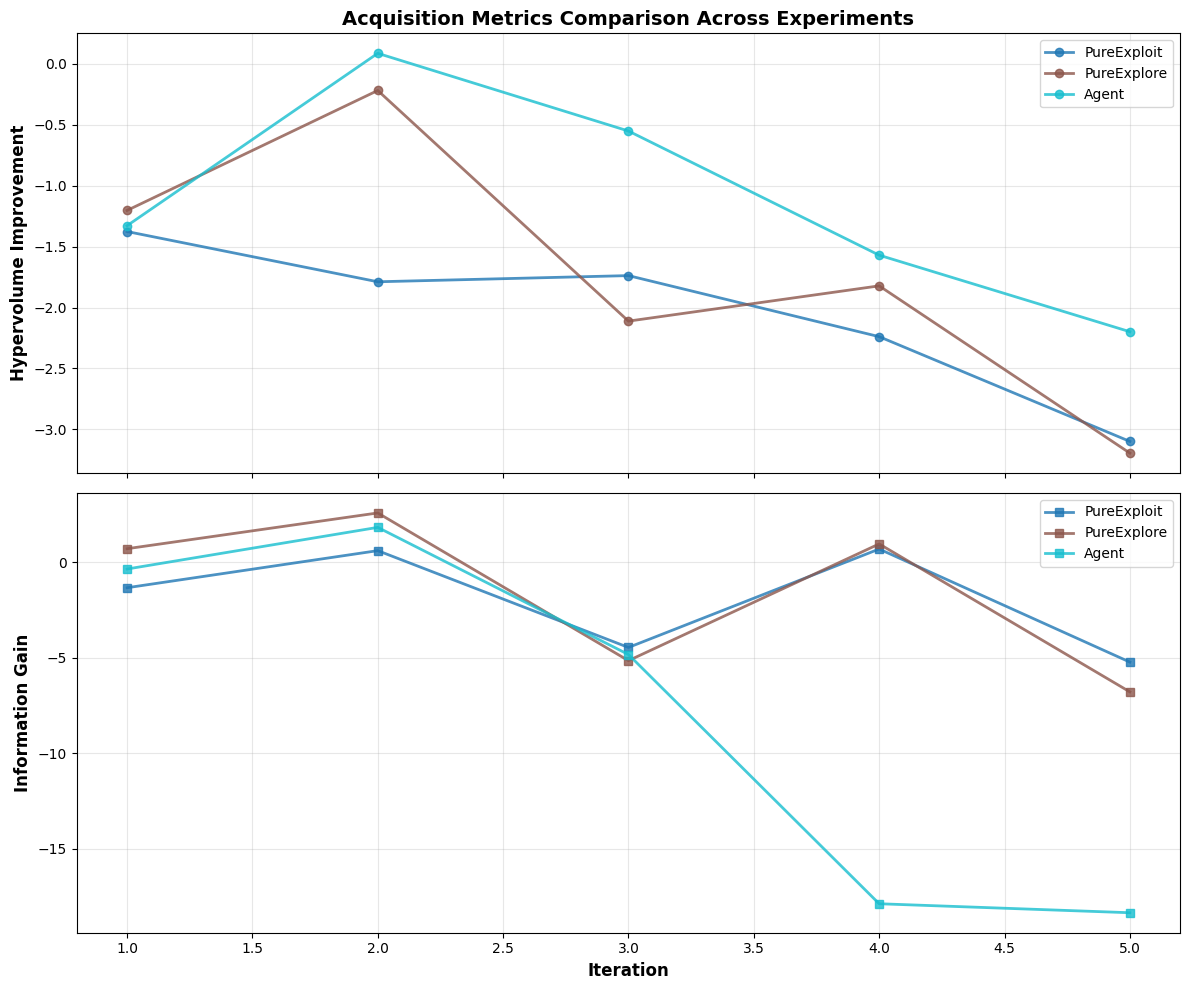

In [ ]:
"""
Plot hypervolume improvement and information gain from convergence CSV.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_acquisition_metrics(convergence_csv_path: str, save_path: str = None):
    """
    Plot HVI and Information Gain over iterations from convergence CSV.
    
    Args:
        convergence_csv_path: Path to the convergence CSV file
        save_path: Optional path to save the figure. If None, displays interactively.
    """
    # Load data
    df = pd.read_csv(convergence_csv_path)
    
    # Filter out iteration 0 (initialization) if desired
    df = df[df['iteration'] > 0]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Plot Hypervolume Improvement
    ax1.plot(df['iteration'], df['hypervolume_improvement'], 
             marker='o', linewidth=2, markersize=6, color='#2E86AB', label='HVI')
    ax1.set_ylabel('Hypervolume Improvement', fontsize=12, fontweight='bold')
    ax1.set_title('Acquisition Function Metrics Over Iterations', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best')
    
    # Plot Information Gain
    ax2.plot(df['iteration'], df['information_gain'], 
             marker='s', linewidth=2, markersize=6, color='#A23B72', label='Info Gain')
    ax2.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Information Gain', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='best')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[Plot] Saved acquisition metrics plot to {save_path}")
    else:
        plt.show()
    
    # Print summary statistics
    print("\n=== Acquisition Metrics Summary ===")
    print(f"Hypervolume Improvement:")
    print(f"  Mean: {df['hypervolume_improvement'].mean():.6f}")
    print(f"  Std:  {df['hypervolume_improvement'].std():.6f}")
    print(f"  Min:  {df['hypervolume_improvement'].min():.6f}")
    print(f"  Max:  {df['hypervolume_improvement'].max():.6f}")
    print(f"\nInformation Gain:")
    print(f"  Mean: {df['information_gain'].mean():.6f}")
    print(f"  Std:  {df['information_gain'].std():.6f}")
    print(f"  Min:  {df['information_gain'].min():.6f}")
    print(f"  Max:  {df['information_gain'].max():.6f}")


def plot_all_experiments_comparison(log_dir: str, experiment_names: list, save_path: str = None):
    """
    Compare HVI and Information Gain across multiple experiments.
    
    Args:
        log_dir: Directory containing experiment subdirectories
        experiment_names: List of experiment names to compare
        save_path: Optional path to save the figure
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(experiment_names)))
    
    for exp_name, color in zip(experiment_names, colors):
        csv_path = os.path.join(log_dir, exp_name, f"{exp_name}_convergence.csv")
        if not os.path.exists(csv_path):
            print(f"[Warning] CSV not found: {csv_path}")
            continue
        
        df = pd.read_csv(csv_path)
        df = df[df['iteration'] > 0]  # Skip initialization
        
        # Plot HVI
        ax1.plot(df['iteration'], df['hypervolume_improvement'], 
                marker='o', linewidth=2, label=exp_name, color=color, alpha=0.8)
        
        # Plot Info Gain
        ax2.plot(df['iteration'], df['information_gain'], 
                marker='s', linewidth=2, label=exp_name, color=color, alpha=0.8)
    
    ax1.set_ylabel('Hypervolume Improvement', fontsize=12, fontweight='bold')
    ax1.set_title('Acquisition Metrics Comparison Across Experiments', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best', fontsize=10)
    
    ax2.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Information Gain', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='best', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[Plot] Saved comparison plot to {save_path}")
    else:
        plt.show()


# Compare multiple experiments
plot_all_experiments_comparison(
    log_dir="results/FeCoNiCrV_K_CTE_Comparison_20260211_153708",
    experiment_names=["PureExploit", "PureExplore", "Agent"],
    save_path="test/output/acquisition_metrics_comparison.png"
)

## Cell 9: Verify Shared Initial Samples

In [ ]:
print("\n" + "="*80)
print("VERIFICATION: All strategies used the same initial samples")
print("="*80)

# Load iteration 0 evaluations from each strategy
eval_qehvi = logger_qehvi.load_evaluations_data()
eval_mesmo = logger_mesmo.load_evaluations_data()
eval_agent = logger_agent.load_evaluations_data()

# Filter iteration 0
eval0_qehvi = eval_qehvi[eval_qehvi['iteration'] == 0].sort_values('point_idx')
eval0_mesmo = eval_mesmo[eval_mesmo['iteration'] == 0].sort_values('point_idx')
eval0_agent = eval_agent[eval_agent['iteration'] == 0].sort_values('point_idx')

print(f"\nIteration 0 samples:")
print(f"  Pure QEHVI: {len(eval0_qehvi)} samples")
print(f"  Pure MESMO: {len(eval0_mesmo)} samples")
print(f"  LLM Agent:  {len(eval0_agent)} samples")

# Check if CTE and K values match
cte_match = np.allclose(eval0_qehvi['CTE'].values, eval0_mesmo['CTE'].values) and \
            np.allclose(eval0_qehvi['CTE'].values, eval0_agent['CTE'].values)
k_match = np.allclose(eval0_qehvi['K'].values, eval0_mesmo['K'].values) and \
          np.allclose(eval0_qehvi['K'].values, eval0_agent['K'].values)

if cte_match and k_match:
    print("\n✅ VERIFICATION PASSED: All strategies have identical initial samples!")
else:
    print("\n❌ VERIFICATION FAILED: Initial samples differ between strategies!")
    print("\nPure QEHVI iteration 0:")
    print(eval0_qehvi[['CTE', 'K', 'score']].to_string(index=False))
    print("\nPure MESMO iteration 0:")
    print(eval0_mesmo[['CTE', 'K', 'score']].to_string(index=False))
    print("\nLLM Agent iteration 0:")
    print(eval0_agent[['CTE', 'K', 'score']].to_string(index=False))

print("="*80)

## Cell 10: Analyze and Compare Results

In [ ]:
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*80)

# Load convergence data
df_qehvi = logger_qehvi.load_convergence_data()
df_mesmo = logger_mesmo.load_convergence_data()
df_agent = logger_agent.load_convergence_data()

# Compute final statistics
scores_qehvi = score_fn(Y_qehvi)
scores_mesmo = score_fn(Y_mesmo)
scores_agent = score_fn(Y_agent)

results_summary = {
    "Strategy": ["Pure QEHVI", "Pure MESMO", "LLM Agent"],
    "Best Score": [
        np.max(scores_qehvi),
        np.max(scores_mesmo),
        np.max(scores_agent),
    ],
    "Mean Score": [
        np.mean(scores_qehvi),
        np.mean(scores_mesmo),
        np.mean(scores_agent),
    ],
    "Std Score": [
        np.std(scores_qehvi),
        np.std(scores_mesmo),
        np.std(scores_agent),
    ],
    "Total Evaluations": [
        len(Y_qehvi),
        len(Y_mesmo),
        len(Y_agent),
    ],
}

df_summary = pd.DataFrame(results_summary)
print("\n" + df_summary.to_string(index=False))

# Find iteration where max score was achieved
def find_max_iteration(eval_df, score_fn, obj1_name, obj2_name):
    max_score = -np.inf
    max_iter = 0
    
    for iteration in sorted(eval_df['iteration'].unique()):
        iter_data = eval_df[eval_df['iteration'] == iteration]
        Y_iter = iter_data[[obj1_name, obj2_name]].to_numpy()
        scores_iter = score_fn(Y_iter)
        
        if scores_iter.max() > max_score:
            max_score = scores_iter.max()
            max_iter = iteration
    
    return max_iter, max_score

qehvi_max_iter, qehvi_max_score = find_max_iteration(eval_qehvi, score_fn, OBJ1_NAME, OBJ2_NAME)
mesmo_max_iter, mesmo_max_score = find_max_iteration(eval_mesmo, score_fn, OBJ1_NAME, OBJ2_NAME)
agent_max_iter, agent_max_score = find_max_iteration(eval_agent, score_fn, OBJ1_NAME, OBJ2_NAME)

print("\n" + "="*80)
print("ITERATION WHERE MAX SCORE WAS ACHIEVED")
print("="*80)
print(f"Pure QEHVI: Iteration {qehvi_max_iter} (Score: {qehvi_max_score:.4f})")
print(f"Pure MESMO: Iteration {mesmo_max_iter} (Score: {mesmo_max_score:.4f})")
print(f"LLM Agent:  Iteration {agent_max_iter} (Score: {agent_max_score:.4f})")

# Determine winner
best_overall = max(qehvi_max_score, mesmo_max_score, agent_max_score)
if best_overall == qehvi_max_score:
    winner = "Pure QEHVI"
elif best_overall == mesmo_max_score:
    winner = "Pure MESMO"
else:
    winner = "LLM Agent"

print(f"\n🏆 WINNER: {winner} (Best Score: {best_overall:.4f})")

# Save summary to CSV
summary_path = os.path.join(OUTPUT_DIR, "comparison_summary.csv")
df_summary.to_csv(summary_path, index=False)
print(f"\nSummary saved to: {summary_path}")

## Cell 11: Plot Convergence Comparison

In [ ]:
# Plot best score convergence over iterations
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each strategy
ax.plot(df_qehvi['iteration'], df_qehvi['best_score'], 
        marker='o', linewidth=2.5, label='Pure QEHVI', markersize=6)
ax.plot(df_mesmo['iteration'], df_mesmo['best_score'], 
        marker='s', linewidth=2.5, label='Pure MESMO', markersize=6)
ax.plot(df_agent['iteration'], df_agent['best_score'], 
        marker='^', linewidth=2.5, label='LLM Agent', markersize=7)

# Mark where max was achieved
ax.axvline(x=qehvi_max_iter, color='C0', linestyle='--', alpha=0.3, linewidth=1.5)
ax.axvline(x=mesmo_max_iter, color='C1', linestyle='--', alpha=0.3, linewidth=1.5)
ax.axvline(x=agent_max_iter, color='C2', linestyle='--', alpha=0.3, linewidth=1.5)

ax.set_xlabel('Iteration', fontsize=14, fontweight='bold')
ax.set_ylabel(f'Best {SCORE_NAME}', fontsize=14, fontweight='bold')
ax.set_title('FeCoNiCrV K/CTE Optimization: Strategy Comparison', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.tick_params(labelsize=11)

plt.tight_layout()
convergence_path = os.path.join(OUTPUT_DIR, "convergence_comparison.png")
plt.savefig(convergence_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Convergence plot saved to: {convergence_path}")

## Cell 12: Per-Iteration Best Score Analysis

In [ ]:
# Compute cumulative best score per iteration
def compute_cumulative_best(eval_df, score_fn, obj1_name, obj2_name):
    iterations = sorted(eval_df['iteration'].unique())
    cumulative_best = []
    
    for iteration in iterations:
        iter_data = eval_df[eval_df['iteration'] <= iteration]
        Y_so_far = iter_data[[obj1_name, obj2_name]].to_numpy()
        scores_so_far = score_fn(Y_so_far)
        cumulative_best.append(scores_so_far.max())
    
    return iterations, cumulative_best

qehvi_iters, qehvi_cum_best = compute_cumulative_best(eval_qehvi, score_fn, OBJ1_NAME, OBJ2_NAME)
mesmo_iters, mesmo_cum_best = compute_cumulative_best(eval_mesmo, score_fn, OBJ1_NAME, OBJ2_NAME)
agent_iters, agent_cum_best = compute_cumulative_best(eval_agent, score_fn, OBJ1_NAME, OBJ2_NAME)

# Create DataFrame
max_len = max(len(qehvi_iters), len(mesmo_iters), len(agent_iters))
per_iter_df = pd.DataFrame({
    'Iteration': range(max_len),
    'QEHVI_Best': qehvi_cum_best + [np.nan] * (max_len - len(qehvi_cum_best)),
    'MESMO_Best': mesmo_cum_best + [np.nan] * (max_len - len(mesmo_cum_best)),
    'Agent_Best': agent_cum_best + [np.nan] * (max_len - len(agent_cum_best)),
})

print("\nCumulative Best Score per Iteration:")
print(per_iter_df.to_string(index=False))

# Save to CSV
per_iter_path = os.path.join(OUTPUT_DIR, "per_iteration_best_scores.csv")
per_iter_df.to_csv(per_iter_path, index=False)
print(f"\nPer-iteration data saved to: {per_iter_path}")

## Cell 13: Final Summary

In [ ]:
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\n📊 Experimental Setup:")
print(f"  Problem: FeCoNiCrV K/CTE Optimization")
print(f"  Objective: Maximize {SCORE_NAME}")
print(f"  Shared initial samples: {INIT_N}")
print(f"  BO iterations: {ITERS}")
print(f"  Batch size: {TOTAL_BATCH_SIZE}")
print(f"  Total evaluations per strategy: {INIT_N + ITERS * TOTAL_BATCH_SIZE}")
print(f"  Random seed: {SEED}")

print(f"\n🏆 Best Results:")
print(f"  Pure QEHVI: {qehvi_max_score:.4f} (iteration {qehvi_max_iter})")
print(f"  Pure MESMO: {mesmo_max_score:.4f} (iteration {mesmo_max_iter})")
print(f"  LLM Agent:  {agent_max_score:.4f} (iteration {agent_max_iter})")

print(f"\n📈 Mean Performance:")
print(f"  Pure QEHVI: {np.mean(scores_qehvi):.4f} ± {np.std(scores_qehvi):.4f}")
print(f"  Pure MESMO: {np.mean(scores_mesmo):.4f} ± {np.std(scores_mesmo):.4f}")
print(f"  LLM Agent:  {np.mean(scores_agent):.4f} ± {np.std(scores_agent):.4f}")

print(f"\n" + "="*80)
print(f"All results saved to: {OUTPUT_DIR}")
print("="*80)